In [1]:
import pickle
import networkx as nx
import pandas as pd
import geopandas as gpd
import random

#Load data
with open(r"C:\Users\luca\Downloads\Lux_public_transport_project\multimodal_network.pkl", "rb") as file:
    multimodal_network = pickle.load(file)

pr_stops  = gpd.read_file(r"C:\Users\luca\Downloads\Lux_public_transport_project\PR_stops.gpkg")
bd_stops = pd.read_csv(r"C:\Users\luca\Downloads\Lux_public_transport_project\district_candidate_stops.csv")

#Re-project pr_stops for analysis
pr_stops = pr_stops.to_crs(epsg=2169)

In [2]:

#Validation checks
#===================================

graph_nodes = set(multimodal_network.nodes())
missing_pr  = set(pr_stops["node"])  - graph_nodes
missing_bd = set(bd_stops["node"]) - graph_nodes

if missing_pr or missing_bd:
    print(f"Missing PR nodes:  {missing_pr}")
    print(f"Missing BD nodes: {missing_bd}")

#Check PR and BD groups
print(f"Business Districts are: {bd_stops['FK_QUART_NAME'].unique().tolist()}")
print(f"P+R facilities are: {pr_stops['name'].unique().tolist()}")

#Check a random edge has a weight and that it is within a reasonable range
rand_edge = random.choice(list(multimodal_network.edges(data=True)))
u, v, attrs = rand_edge
print(f"Edge goes from {u} to {v} and has attributes {attrs}")
if ("weight" in attrs) and (attrs["weight"] <= 9999):
    print("Edges are reasonable and functional")

Business Districts are: ['Gasperich', 'Gare', 'Kirchberg', 'Ville Haute', 'Grund']
P+R facilities are: ['Gare', 'Kockelscheuer', 'Hollerich', 'Howald', 'Stadion', 'Héienhaff']
Edge goes from walk_445121638 to walk_1327877587 and has attributes {'osmid': [645024122, 978727847], 'highway': 'secondary', 'lanes': '2', 'maxspeed': ['90', '50'], 'name': 'Rue de Reckenthal', 'ref': 'CR 230', 'oneway': False, 'reversed': False, 'length': 72.33485679459969, 'geometry': <LINESTRING (73636.8 76410.688, 73658.323 76421.141, 73668.321 76425.923, 73...>, 'edge_type': 'walk', 'mode': 'walk', 'weight': 0.8611292475547583}
Edges are reasonable and functional


In [3]:
import numpy as np

#First we create a P+R x BD mean shortest travel time matrix


#Group origins and destinations into dictionaries
origin_pr = pr_stops.groupby("name")["node"].apply(list).to_dict()
destination_bd = bd_stops.groupby("FK_QUART_NAME")["node"].apply(list).to_dict()

#For each PR stop, we create a dict with the following structure:
# travel_time_min = {pr: {stop: shortest_travel_times}}
travel_time_min = {}
for pr, stops in origin_pr.items():

    
    nodes_stored = {}
    for stop in stops:
        travel_time = nx.single_source_dijkstra_path_length(
            multimodal_network,
            stop,
            cutoff=120,
            weight="weight"
        )

        #We want absolute minimum so this makes sure that the shortest time for each node is stored.
        for node, time in travel_time.items():
            if (node not in nodes_stored) or (time < nodes_stored[node]):
                nodes_stored[node] = time

    travel_time_min[pr] = nodes_stored

# Store [min, mean, max] travel times for each BD

#pr_travel_time = {pr: {bd: [min,mean,max]} }
pr_travel_time = {}
for pr, travel_times in travel_time_min.items():


    pr_travel_time[pr] = {}
    for bd, bd_nodes in destination_bd.items():

        #For every stop in the business district, we create a list of node times that the pr stop can reach.
        bd_node_times = [travel_times.get(node, 9999) for node in bd_nodes]
        reachable = [t for t in bd_node_times if t != 9999]

        #We save the min time in that list, the mean time in that list and the max time in that list
        times = [
            np.min(reachable) if reachable else 9999,
            np.mean(reachable) if reachable else 9999,
            np.max(reachable) if reachable else 9999
        ]
        pr_travel_time[pr][bd] = times


# For each P+R, average the per-BD min, mean and max travel times
# over all business districts.
for pr, bd_dict in pr_travel_time.items():
    bd_times_reach = [
        [t for t in col if t != 9999]
        for col in zip(*list(bd_dict.values()))
    ]

    pr_travel_time[pr]["Average Min BD time"] = np.mean(bd_times_reach[0]) if bd_times_reach[0] else 9999
    pr_travel_time[pr]["Average Mean BD time"] = np.mean(bd_times_reach[1]) if bd_times_reach[1] else 9999
    pr_travel_time[pr]["Average Max BD time"] = np.mean(bd_times_reach[2]) if bd_times_reach[2] else 9999


#Finally, we have a matrix which has the P+R facility as the index and the BD as the columns, except the BD mean columns
pr_bd_matrix = (
    pd.DataFrame.from_dict(pr_travel_time, orient="index")
    .reset_index()
    .rename(columns={"index": "P+R Facility"})
)


Heatmap saved ✓ 


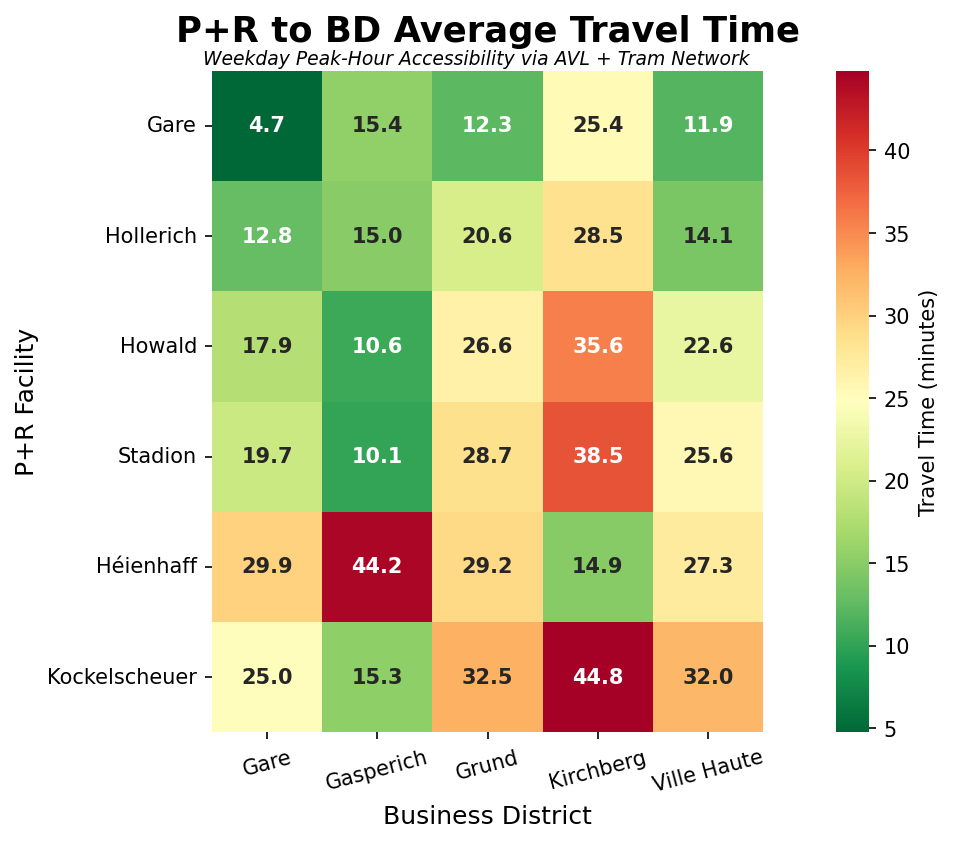

In [4]:
# Heatmap of mean P+R to BD travel times
import seaborn as sns
import matplotlib.pyplot as plt

# Heatmap matrix keeps only BD means
bd_cols = list(destination_bd)

plot_matrix = (
    pr_bd_matrix
    .set_index("P+R Facility")[bd_cols]
    .apply(lambda col: col.str[1])
    .reindex(["Gare", "Hollerich", "Howald",
              "Stadion", "Héienhaff", "Kockelscheuer"])
)

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

sns.heatmap(
    plot_matrix,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    square=True,
    cbar_kws={"label": "Travel Time (minutes)"},
    annot_kws={"size": 10, "weight": "bold"},
    ax=ax
)

ax.set_title("P+R to BD Average Travel Time", fontsize=17, weight="bold", pad=14)
plt.suptitle("Weekday Peak-Hour Accessibility via AVL + Tram Network", fontsize=9, style="italic", y=0.89, x=0.6)
ax.set_xlabel("Business District", fontsize=12)
ax.set_ylabel("P+R Facility", fontsize=12)

plt.xticks(rotation=15)
plt.yticks(rotation=0)
plt.tight_layout()

fig.savefig(
    "heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
print("Heatmap saved ✓ ")
plt.show()


Bar chart saved ✓ 


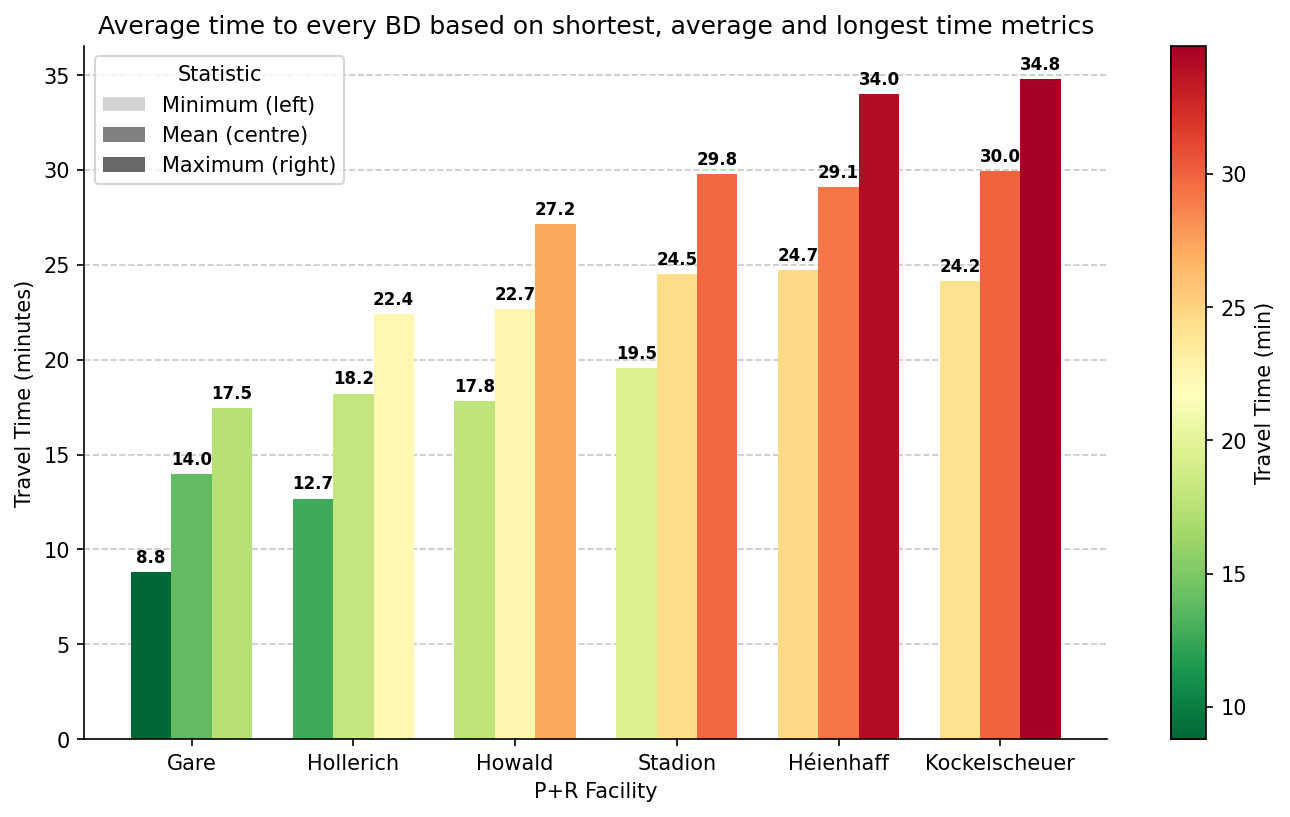

In [5]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Patch


#Here, we create a per BD mean bar chart with all three statistics.
#This represents the average shortest time to get to a BD using each statistic

#The graph should be sorted based on the mean BD values
sorted_matrix = pr_bd_matrix.sort_values(
    "Average Mean BD time",
    ascending=True
)

facilities = sorted_matrix["P+R Facility"]
min_times = sorted_matrix["Average Min BD time"]
mean_times = sorted_matrix["Average Mean BD time"]
max_times = sorted_matrix["Average Max BD time"]

x = np.arange(len(facilities))
width = 0.25

all_times = np.concatenate([
    min_times.values,
    mean_times.values,
    max_times.values
])

norm = mcolors.Normalize(
    vmin=all_times.min(),
    vmax=all_times.max()
)

colors_min = [cm.RdYlGn_r(norm(v)) for v in min_times]
colors_mean = [cm.RdYlGn_r(norm(v)) for v in mean_times]
colors_max = [cm.RdYlGn_r(norm(v)) for v in max_times]

fig, ax = plt.subplots(figsize=(11, 6), dpi=150)

bars_min = ax.bar(x - width, min_times, width, color=colors_min)
bars_mean = ax.bar(x, mean_times, width, color=colors_mean)
bars_max = ax.bar(x + width, max_times, width, color=colors_max)

for bars in [bars_min, bars_mean, bars_max]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f"{bar.get_height():.1f}",
            ha="center",
            va="bottom",
            fontsize=8,
            weight="bold"
        )

legend_handles = [
    Patch(facecolor="lightgrey", label="Minimum (left)"),
    Patch(facecolor="grey", label="Mean (centre)"),
    Patch(facecolor="dimgray", label="Maximum (right)")
]

ax.legend(handles=legend_handles, title="Statistic")

sm = ScalarMappable(norm=norm, cmap=cm.RdYlGn_r)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Travel Time (min)")

plt.title("Average time to every BD based on shortest, average and longest time metrics")

ax.set_xticks(x)
ax.set_xticklabels(facilities)

ax.set_ylabel("Travel Time (minutes)")
ax.set_xlabel("P+R Facility")

ax.yaxis.grid(True, linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

sns.despine()

fig.savefig(
    "barchart.png",
    dpi=300,
    bbox_inches="tight"
)
print("Bar chart saved ✓ ")

plt.show()


In [6]:
#Finally, we create three tables. The first ranks the P+R facilities in ascending order

ranking_df = pd.DataFrame({
    "Min Rank": (
        pr_bd_matrix
        .sort_values("Average Min BD time")
        ["P+R Facility"]
        .tolist()
    ),
    "Mean Rank": (
        pr_bd_matrix
        .sort_values("Average Mean BD time")
        ["P+R Facility"]
        .tolist()
    ),
    "Max Rank": (
        pr_bd_matrix
        .sort_values("Average Max BD time")
        ["P+R Facility"]
        .tolist()
    )
})

print("Ranking comparison\n")
print(ranking_df)
print()

#The next computes a mean rank based on the three statistics
rank_cols = [
    "Average Min BD time",
    "Average Mean BD time",
    "Average Max BD time"
]

rank_comparison = (
    pr_bd_matrix
    .set_index("P+R Facility")[rank_cols]
    .rank(method="dense")
)

rank_comparison["Mean Rank"] = rank_comparison.mean(axis=1)

print("Mean ranking:\n")
print(rank_comparison["Mean Rank"].sort_values())
print()

#Finally, using 25 minutes as a threshold, we find the amount of districts that take less than 25 minutes to get to on average.
print("Mean accessibility for each P+R facility\n")
for pr, row in plot_matrix.iterrows():
    under_25 = (row < 25).sum()
    print(f"{pr}: {under_25}/{len(row)} districts under 25 min")


Ranking comparison

        Min Rank      Mean Rank       Max Rank
0           Gare           Gare           Gare
1      Hollerich      Hollerich      Hollerich
2         Howald         Howald         Howald
3        Stadion        Stadion        Stadion
4  Kockelscheuer      Héienhaff      Héienhaff
5      Héienhaff  Kockelscheuer  Kockelscheuer

Mean ranking:

P+R Facility
Gare             1.000000
Hollerich        2.000000
Howald           3.000000
Stadion          4.000000
Héienhaff        5.333333
Kockelscheuer    5.666667
Name: Mean Rank, dtype: float64

Mean accessibility for each P+R facility

Gare: 4/5 districts under 25 min
Hollerich: 4/5 districts under 25 min
Howald: 3/5 districts under 25 min
Stadion: 2/5 districts under 25 min
Héienhaff: 1/5 districts under 25 min
Kockelscheuer: 1/5 districts under 25 min


In [7]:
#Isochrone generation
from shapely.geometry import Point
from shapely.ops import unary_union


time_bands = [15, 20, 30, 45]  # minutes
graph_crs   = multimodal_network.graph["crs"]

#Extract x,y for every node that has coordinates
node_points = {
    node: (data["x"], data["y"])
    for node, data in multimodal_network.nodes(data=True)
    if ("x" in data) and ("y" in data)
}

#For each P+R facility build a buffered isochrone per time band
pr_isochrones = {}

#First create cumulative isochrones
for pr, nodes in travel_time_min.items():

    #filter nodes
    valid_nodes = {node: time for node, time in nodes.items() if node in node_points}

    cumulative_iso = {}

    for iso_time in time_bands:
        iso_points = [
            Point(node_points[node])
            for node, time in valid_nodes.items()
            if time <= iso_time
        ]

        #If not enough points, skip
        if len(iso_points) < 3:
            print(f"  [skip] {pr} @ {iso_time} min — only {len(iso_points)} node(s)")
            continue

        #Smooths out isochrones
        merged = unary_union([p.buffer(150) for p in iso_points])
        merged = merged.buffer(100).buffer(-100)
        merged = merged.simplify(20, preserve_topology=True)

        cumulative_iso[iso_time] = merged

    #Then take the difference to create rings
    pr_isochrones[pr] = {}
    previous_iso = None

    for iso_time, current_iso in cumulative_iso.items():  
        ring = current_iso if previous_iso is None else current_iso.difference(previous_iso)
        pr_isochrones[pr][iso_time] = ring
        previous_iso = current_iso

#When exporting, we have three files:
#Layers lets you look at each isochrone map separately
#Atlas is used to generate the maps, combines the isochrones into one layer
#Stops is used to generate maps, finds the centroid. pr_stops can be used if you want the exact stops.

OUTPUT_CRS   = 4326
OUTPUT_GPKG  = {
    "layers"  : "pr_isochrones_layers.gpkg",
    "atlas"   : "pr_isochrones_atlas.gpkg",
    "stops"   : "pr_stops_atlas.gpkg",
}

#Create records out of the isochrones
atlas_records = []
for pr, iso_dict in pr_isochrones.items():
    pr_records = [
        {"pr_name": str(pr), "time_min": iso_time, "geometry": geom}
        for iso_time, geom in iso_dict.items()
    ]
    atlas_records.extend(pr_records)


    layer_name = str(pr).replace(" ", "_").replace("/", "_")

    (
        gpd.GeoDataFrame(pr_records, geometry="geometry", crs=graph_crs)
        .to_crs(OUTPUT_CRS)
        .to_file(OUTPUT_GPKG["layers"], layer=layer_name, driver="GPKG")
    )

# Combined Atlas isochrone layer
(
    gpd.GeoDataFrame(atlas_records, geometry="geometry", crs=graph_crs)
    .to_crs(OUTPUT_CRS)
    .to_file(OUTPUT_GPKG["atlas"], layer="PR_isochrone_atlas", driver="GPKG")
)

# P+R centroid Atlas layer
pr_stop_records = [
    {"pr_name": pr_name, "geometry": group.geometry.union_all().centroid}
    for pr_name, group in pr_stops.groupby("name")
]
(
    gpd.GeoDataFrame(pr_stop_records, geometry="geometry", crs=pr_stops.crs)
    .to_crs(OUTPUT_CRS)
    .to_file(OUTPUT_GPKG["stops"], layer="PR_stop_atlas", driver="GPKG")
)

print(f"Exported {len(atlas_records)} isochrone features across {len(pr_isochrones)} P+Rs")


Exported 24 isochrone features across 6 P+Rs
